# Global poverty and economic inequality (2015–2024)

Dataset: [hamnamunir/global-poverty-and-economic-inequality-2015-2024](https://www.kaggle.com/datasets/hamnamunir/global-poverty-and-economic-inequality-2015-2024) — CSV **`global_poverty_economic_inequality.csv`**.

Each row is a **country–year synthetic panel** tying national development indicators—**poverty rate**, **Gini coefficient**, **HDI**, **GDP per capita**, access and infrastructure shares, labour-market and environmental measures—to **`region`** and **`income_group`** taxonomies.

**Reading these charts:** correlations and regression lines describe **patterns in one compiled table**, not proof of causal mechanisms. Comparisons slice the same longitudinal mix of countries differently (by region vs income strata).

---

Style note: exploratory flow follows the same playbook as *[Costa Rican Poverty — distributions and correlations](https://www.kaggle.com/code/nicapotato/costa-rican-poverty-distributions-and-corr)*—start with distributions, then layer multivariate correlation views—using seaborn grids plus **`pandas` ⇢ `nica`** helpers from **`nicaviz`**.

In [1]:
!pip install nicaviz

In [2]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")


def _distplot_compat(a, ax=None, **kwargs):
    """Seaborn ≥0.12 removed `sns.distplot`; nicaviz still calls it internally."""
    kde_kws = kwargs.pop("kde_kws", {}) or {}
    if ax is None:
        ax = plt.gca()
    sns.histplot(a, ax=ax, kde=True, stat="density", kde_kws=kde_kws, **kwargs)
    return ax


if not hasattr(sns, "distplot"):
    sns.distplot = _distplot_compat

import nicaviz  # noqa: F401 — registers `DataFrame.nica` accessor

## Load data

On Kaggle, files live under **`/kaggle/input/…`**. On macOS, **`kagglehub`** pulls the archive into its cache unless you mirror the CSV at **`eda/data/global_poverty_economic_inequality.csv`**.


In [3]:
DATA_SLUG = "hamnamunir/global-poverty-and-economic-inequality-2015-2024"
CSV_NAME = "global_poverty_economic_inequality.csv"


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        named = sorted(kaggle_root.rglob(CSV_NAME), key=lambda p: p.stat().st_size, reverse=True)
        if named:
            return named[0]
        any_csv = list(kaggle_root.rglob("*.csv"))
        if any_csv:
            return max(any_csv, key=lambda p: p.stat().st_size)
        raise FileNotFoundError(f"No CSV under {kaggle_root}")

    local = Path("data") / CSV_NAME
    if local.exists():
        return local.resolve()

    root = Path(kagglehub.dataset_download(DATA_SLUG))
    nested = list(root.glob(f"**/{CSV_NAME}"))
    if nested:
        return nested[0]

    csvs = list(root.rglob("*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No CSV under kagglehub path {root}")
    return max(csvs, key=lambda p: p.stat().st_size)


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
print(df.shape[0], "rows ×", df.shape[1], "cols")


CSV: /kaggle/input/datasets/hamnamunir/global-poverty-and-economic-inequality-2015-2024/global_poverty_economic_inequality.csv
10000 rows × 25 cols


## First look

Random sample, dtypes, and numeric **`describe`** to ground every later plot.

In [4]:
display(df.sample(5, random_state=42))
display(df.dtypes.to_frame("dtype"))
display(df.describe().T)

CAT_COLS = ["region", "income_group"]
ID_LIKE = ["record_id", "country"]
NUM_COLS = [c for c in df.columns if c not in CAT_COLS + ID_LIKE]


,record_id,year,country,region,income_group,gdp_per_capita_usd,poverty_rate_pct,gini_coefficient,hdi_score,unemployment_rate_pct,...,clean_water_access_pct,internet_penetration_pct,female_labor_participation_pct,social_protection_coverage_pct,income_share_top10_pct,income_share_bottom40_pct,urban_population_pct,remittances_pct_of_gdp,foreign_aid_million_usd,co2_per_capita_tonnes
6252,POV0006253,2021,South Africa,Sub-Saharan Africa,Upper-Middle Income,7398,3.54,36.37,0.682,11.39,...,94.1,81.8,62.3,69.3,33.3,12.7,73.7,2.5,11,3.94
4684,POV0004685,2021,UK,Europe,High Income,53986,0.54,29.08,0.916,9.19,...,98.6,99.0,55.3,85.0,32.9,18.0,76.6,1.6,0,14.31
1731,POV0001732,2018,Senegal,Sub-Saharan Africa,Lower-Middle Income,1754,9.17,38.53,0.617,10.55,...,73.8,43.1,64.2,44.5,34.5,21.6,47.8,11.6,188,1.07
4742,POV0004743,2017,Morocco,Middle East & North Africa,Lower-Middle Income,3928,38.55,48.07,0.539,6.97,...,80.5,47.4,22.9,28.8,34.5,11.9,50.1,10.3,82,1.42
4521,POV0004522,2022,China,East Asia,Upper-Middle Income,16048,6.61,49.60,0.695,14.23,...,82.3,60.9,43.6,64.0,54.2,10.3,65.2,1.3,39,4.86


,dtype
record_id,object
year,int64
country,object
region,object
income_group,object
gdp_per_capita_usd,int64
poverty_rate_pct,float64
gini_coefficient,float64
hdi_score,float64
unemployment_rate_pct,float64


,count,mean,std,min,25%,50%,75%,max
year,10000.0,2020.113500,2.708865,2015.000,2018.0000,2020.000,2022.0000,2024.00
gdp_per_capita_usd,10000.0,13365.287600,22003.606806,470.000,1518.0000,2920.000,11478.2500,107221.00
poverty_rate_pct,10000.0,22.881256,20.620316,0.500,4.7875,16.980,35.6925,74.87
gini_coefficient,10000.0,42.139246,7.628379,20.300,36.7400,42.075,47.9125,63.51
hdi_score,10000.0,0.656249,0.162896,0.352,0.5350,0.649,0.7590,0.99
unemployment_rate_pct,10000.0,8.965726,3.770972,-1.020,6.1200,8.640,11.5300,21.31
inflation_rate_pct,10000.0,10.112306,8.062916,-2.910,4.7200,8.160,11.8700,38.77
literacy_rate_pct,10000.0,73.955290,17.789112,35.100,60.4000,74.900,89.8000,99.90
life_expectancy_years,10000.0,69.554950,8.349090,52.000,63.8000,69.500,75.7000,86.30
child_mortality_per_1000,10000.0,36.769500,31.345278,1.500,10.4000,29.400,53.5000,119.70


### Categorical snapshot (`nica.categorical_describe`)

Low-cardinality facets (`region`, `income_group`) anchor both univariate bars and later heatmaps.

In [5]:
display(df[CAT_COLS].nica.categorical_describe())


Dataframe Dimension: 10000 Rows, 2 Columns


,Unique,Missing,dtype,ValCount 1,Occ,ValCount 2,Occ,ValCount 3,Occ,ValCount 4,Occ,ValCount 5,Occ
Column,,,,,,,,,,,,,
region,10,0,object,Sub-Saharan Africa,3143,South Asia,1721,Latin America & Caribbean,1184,Southeast Asia,1083,East Asia,828.0
income_group,4,0,object,Lower-Middle Income,3692,Low Income,2525,Upper-Middle Income,2090,High Income,1693,NaN,NaN


## Univariate analysis

- **Categorical:** horizontal count plots (via **`mass_plot` / `countplot`**) so country-group labels stay readable.
- **Continuous:** two `catplot(kind="box")` sweeps (hue by **`income_group`**, then separately by **`region`**) across all numeric fields in a wrap grid with **per-variable y-scales** (`sharey=False`) so disparate units (GDP vs rates) stay readable side by side—mirrors the Costa Rica notebook’s “show every distribution” sweep.


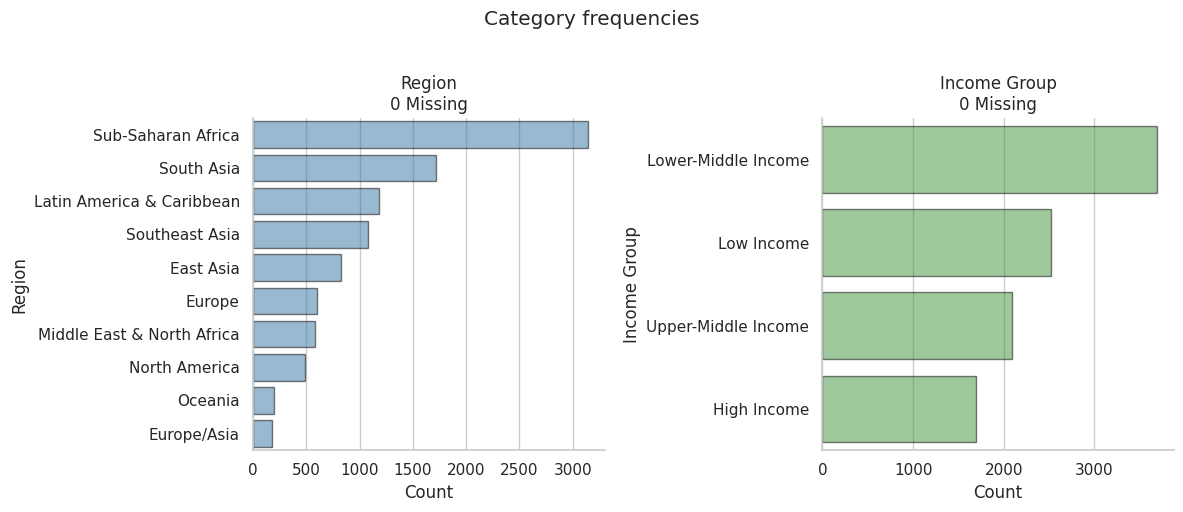

In [6]:
fig = df.nica.mass_plot(CAT_COLS, "countplot", columns=2, figsize=(12, 5))
fig.suptitle("Category frequencies", y=1.02)
plt.tight_layout()
plt.show()


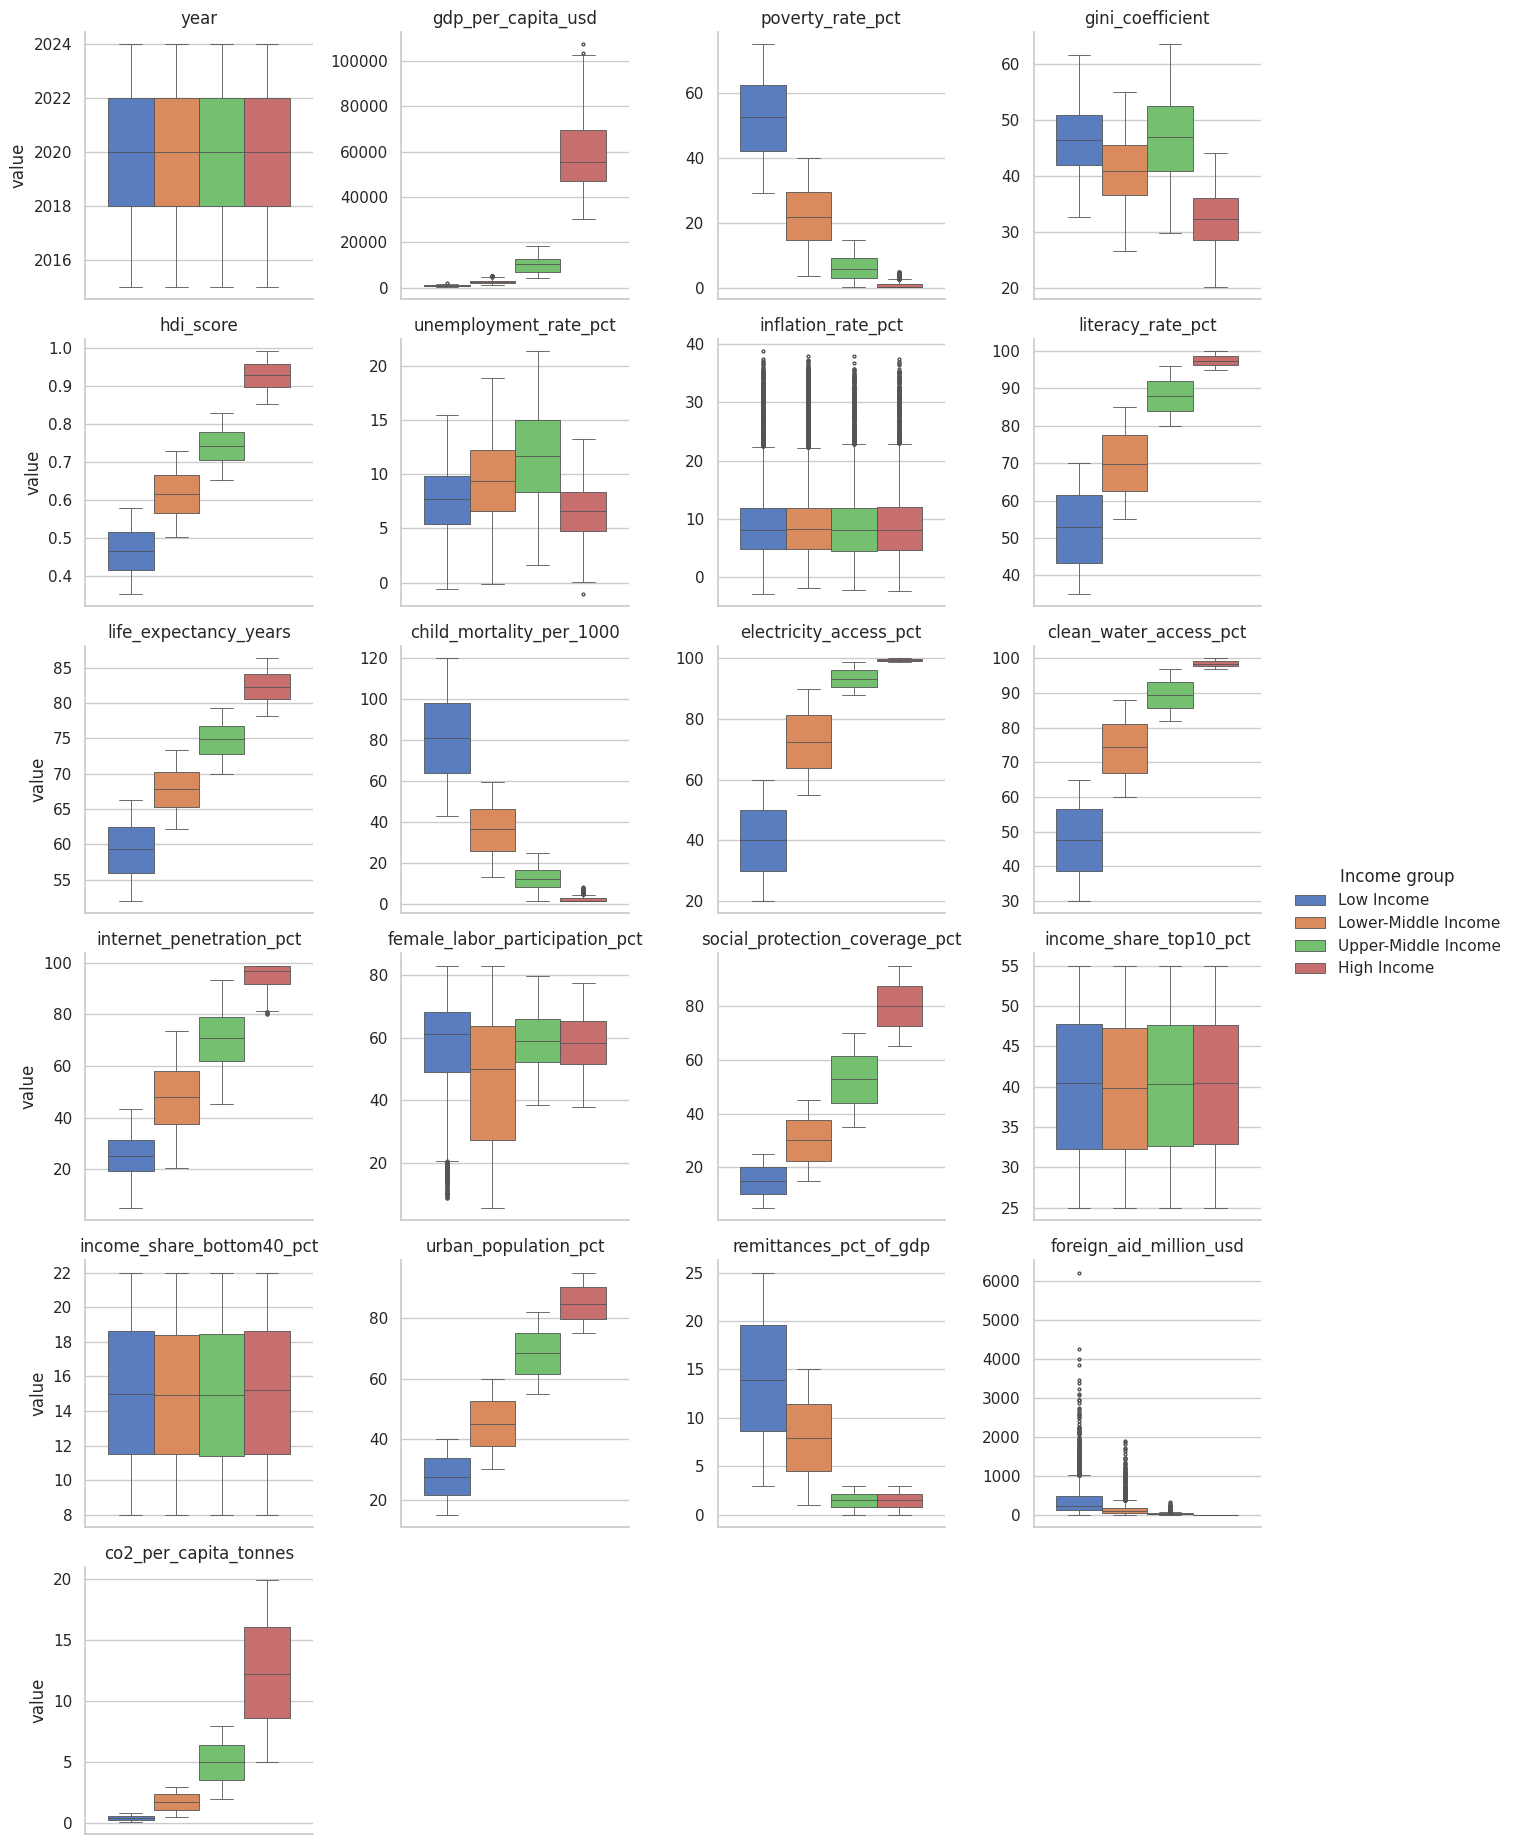

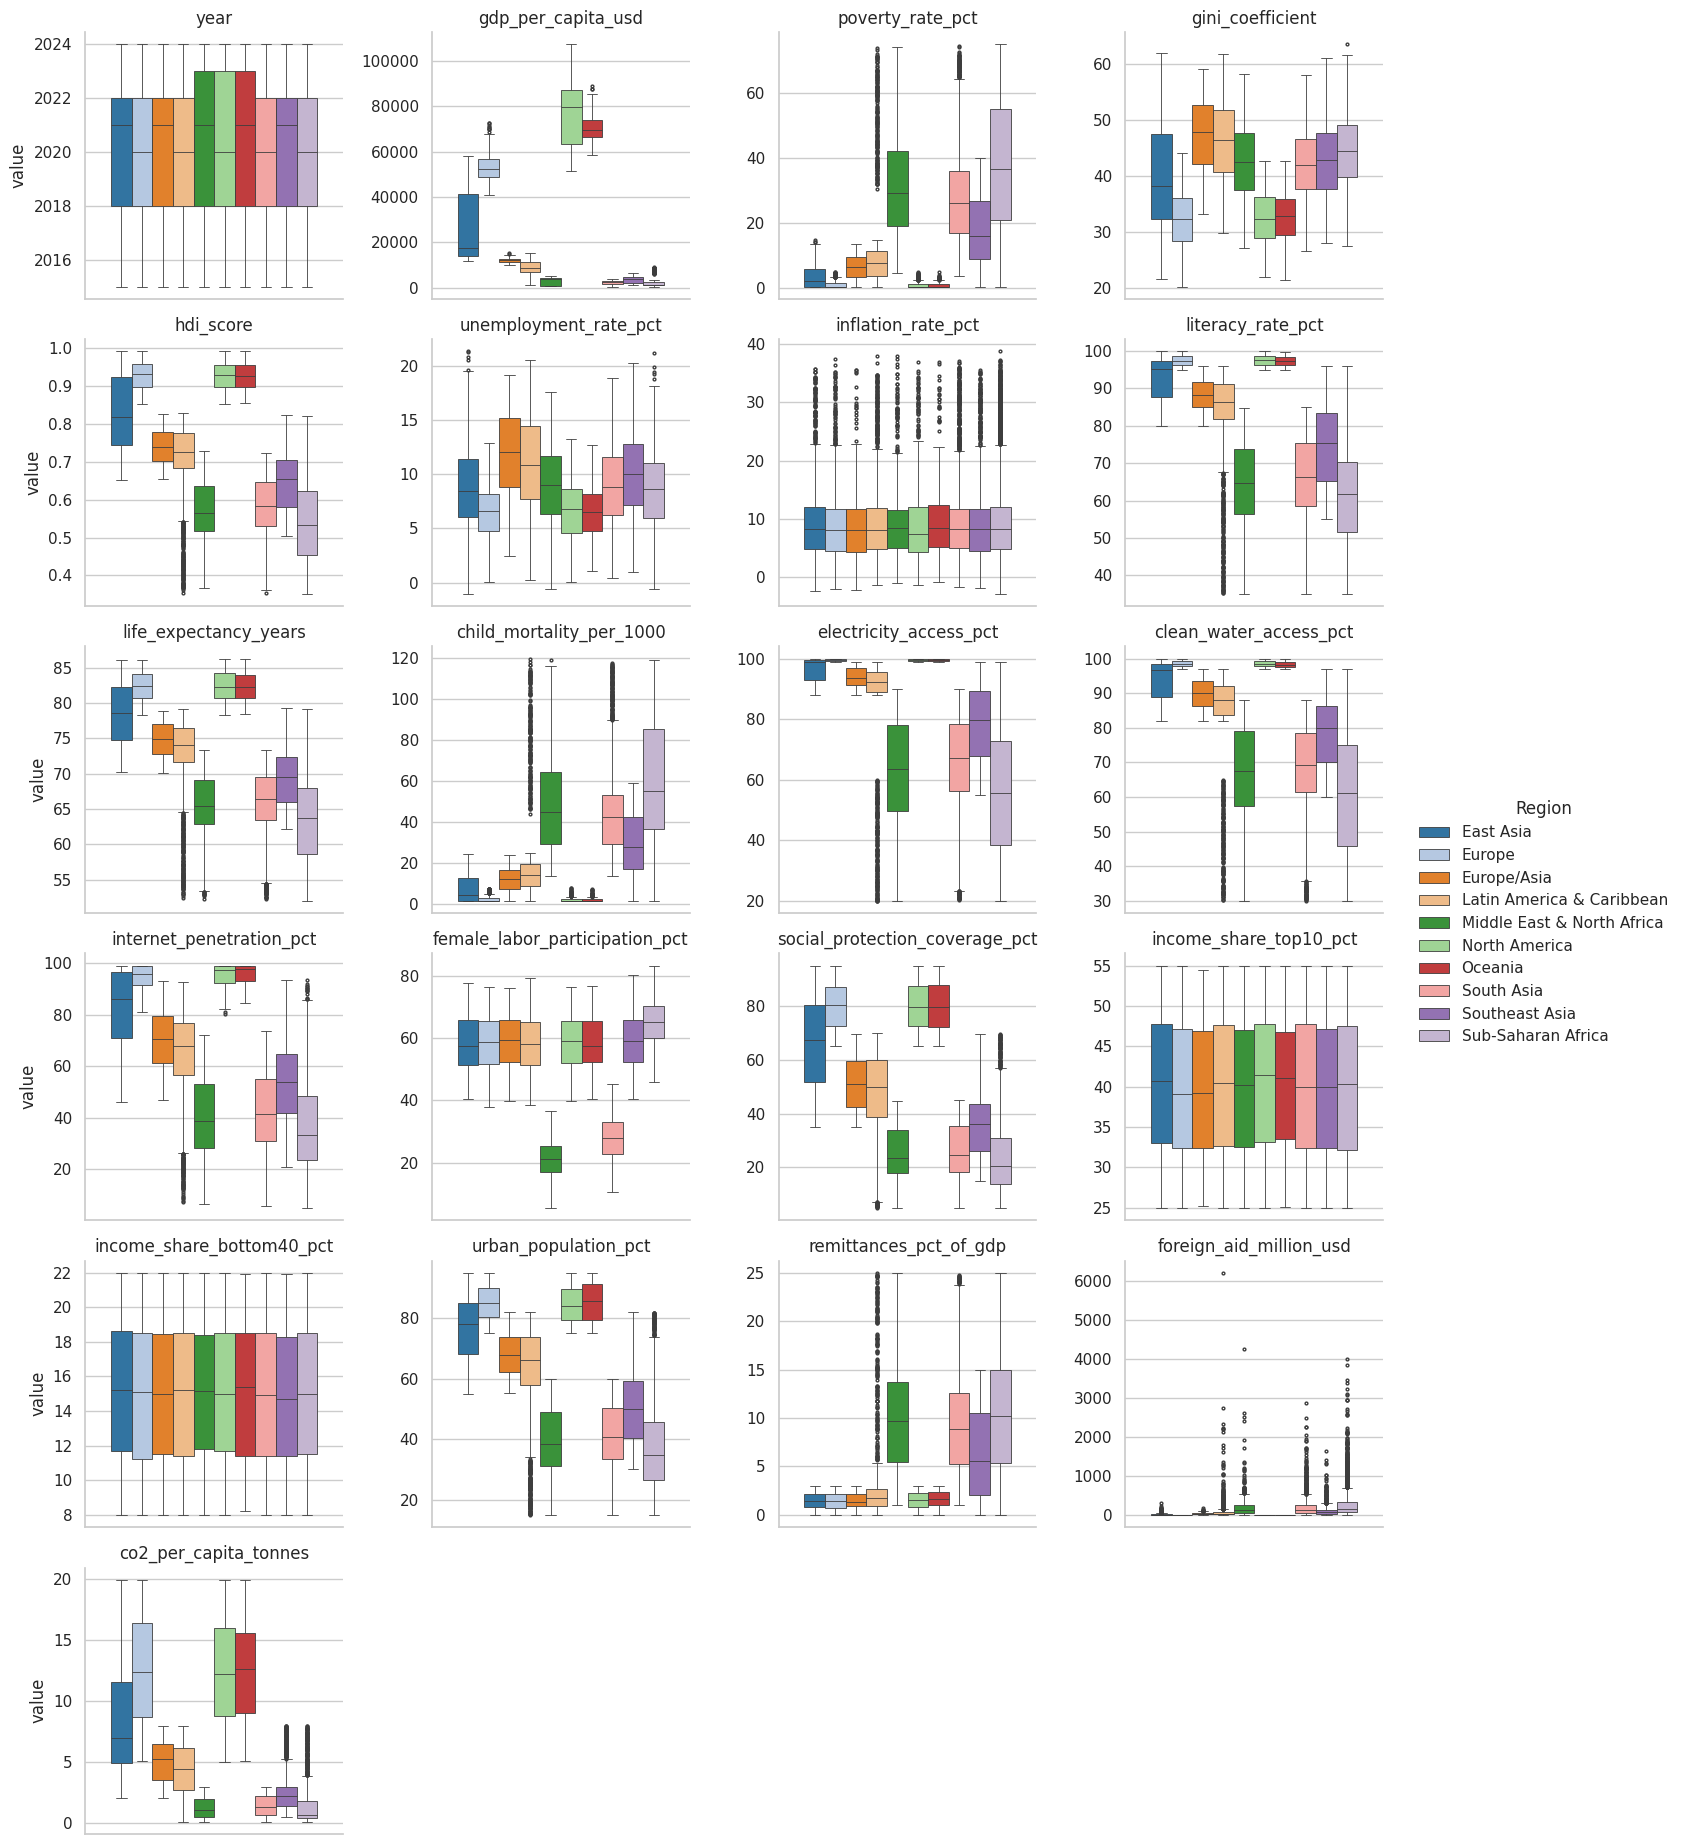

In [7]:
long = df.melt(
    id_vars=CAT_COLS,
    value_vars=NUM_COLS,
    var_name="variable",
    value_name="value",
)

_income_levels = ["Low Income", "Lower-Middle Income", "Upper-Middle Income", "High Income"]
hue_order_income = [l for l in _income_levels if l in long["income_group"].unique()]

g_inc = sns.catplot(
    data=long,
    y="value",
    col="variable",
    hue="income_group",
    hue_order=hue_order_income,
    kind="box",
    col_wrap=4,
    sharey=False,
    height=3.1,
    aspect=1.05,
    linewidth=0.6,
    fliersize=2,
    dodge=True,
    palette="muted",
)
g_inc.set_axis_labels("", "value")
g_inc.set_titles("{col_name}")
g_inc._legend.set_title("Income group")
g_inc.tight_layout()
plt.show()

hue_order_region = sorted(long["region"].dropna().unique())
g_reg = sns.catplot(
    data=long,
    y="value",
    col="variable",
    hue="region",
    hue_order=hue_order_region,
    kind="box",
    col_wrap=4,
    sharey=False,
    height=3.1,
    aspect=1.15,
    linewidth=0.6,
    fliersize=2,
    dodge=True,
    palette="tab20",
)
g_reg.set_axis_labels("", "value")
g_reg.set_titles("{col_name}")
g_reg._legend.set_title("Region")
g_reg.tight_layout()
plt.show()


### Univariate reflection

- **Income groups** are intentionally imbalanced (more lower-middle than high-income rows), so any raw count plot should be read beside **row-normalized** heatmaps later.
- **Inequality and welfare fields** (Gini, poverty, HDI, access rates) show where supports might cluster in multivariate space—long tails would push us toward robust methods in modeling, but here we stay descriptive.
- **Macro controls** such as **GDP per capita**, **inflation**, and **unemployment** provide cross-national context for the distributional statistics.


## Multivariate analysis

1. **Correlation matrix** — dense overview of how national indicators co-move.
2. **`rank_correlations_plots`** — nicaviz surfaces the strongest linear (polynomial) pairwise trends, echoing the Costa Rica correlation tour.
3. **`lmplot`** — poverty vs inequality with **`income_group`** hue; legend parked to the right.
4. **Box/violin views** — continuous outcome vs **income_group**.
5. **Two-way categorical** — row-normalized **`crosstab`** heatmap + **`pivot_plots`** for mean poverty across **region × income_group**.

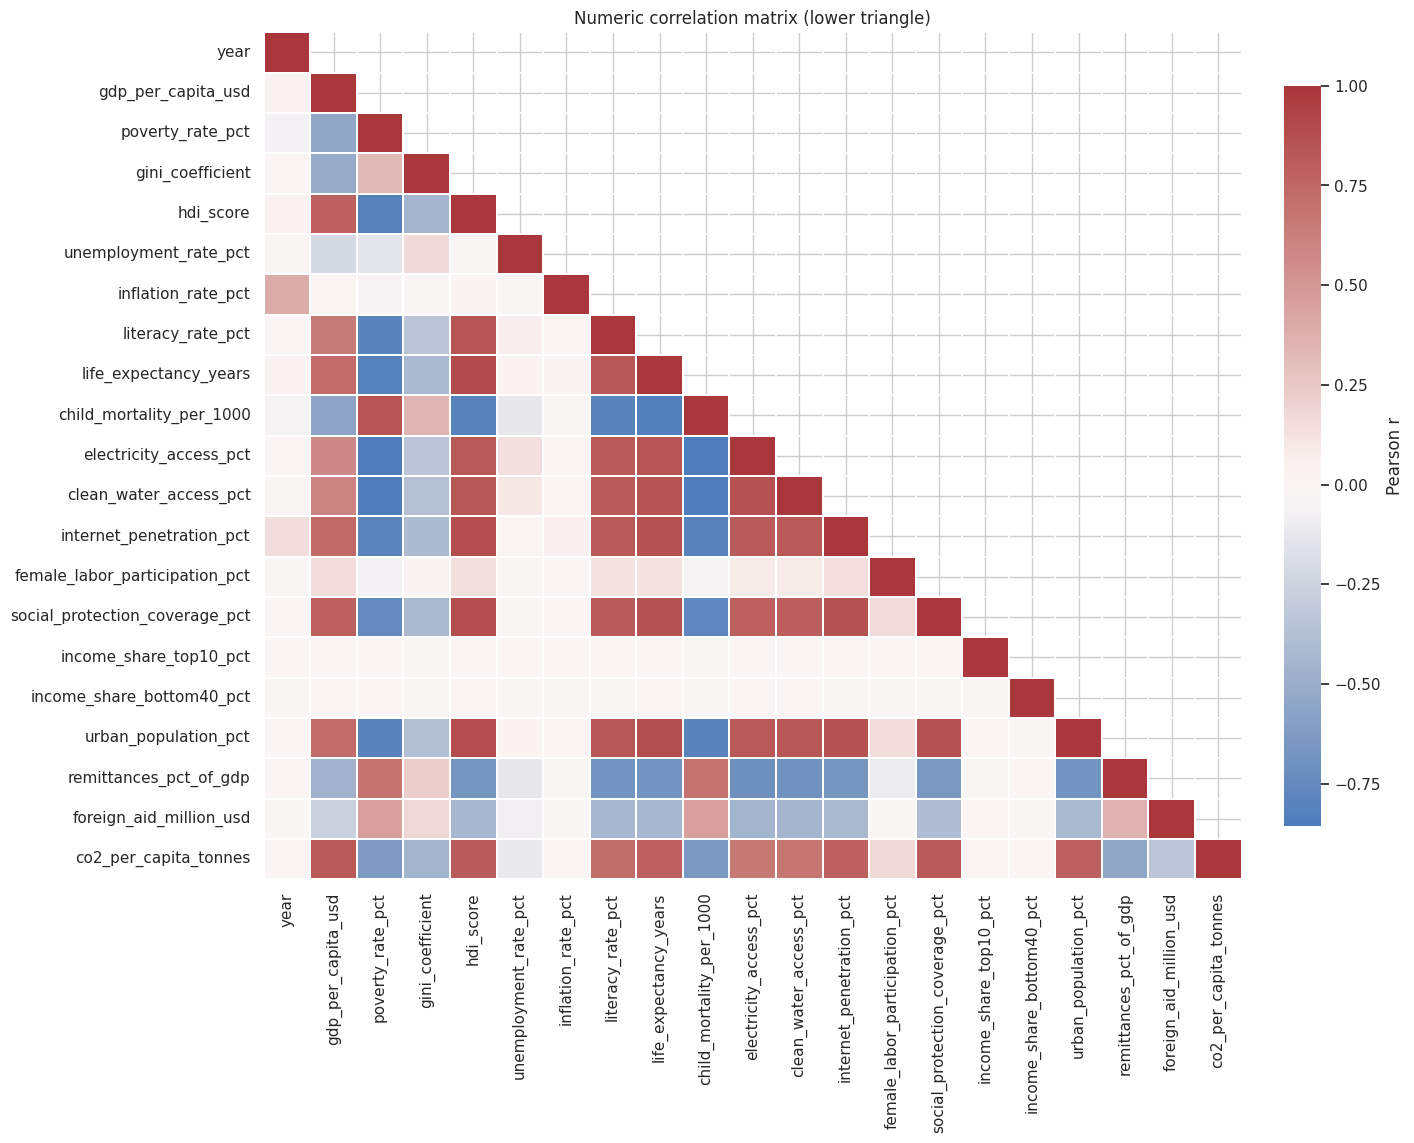

In [8]:
cm = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm,
    mask=mask,
    cmap="vlag",
    center=0,
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Pearson r", "fraction": 0.035, "pad": 0.04},
)
ax.set_title("Numeric correlation matrix (lower triangle)")
plt.subplots_adjust(right=0.88)
plt.show()


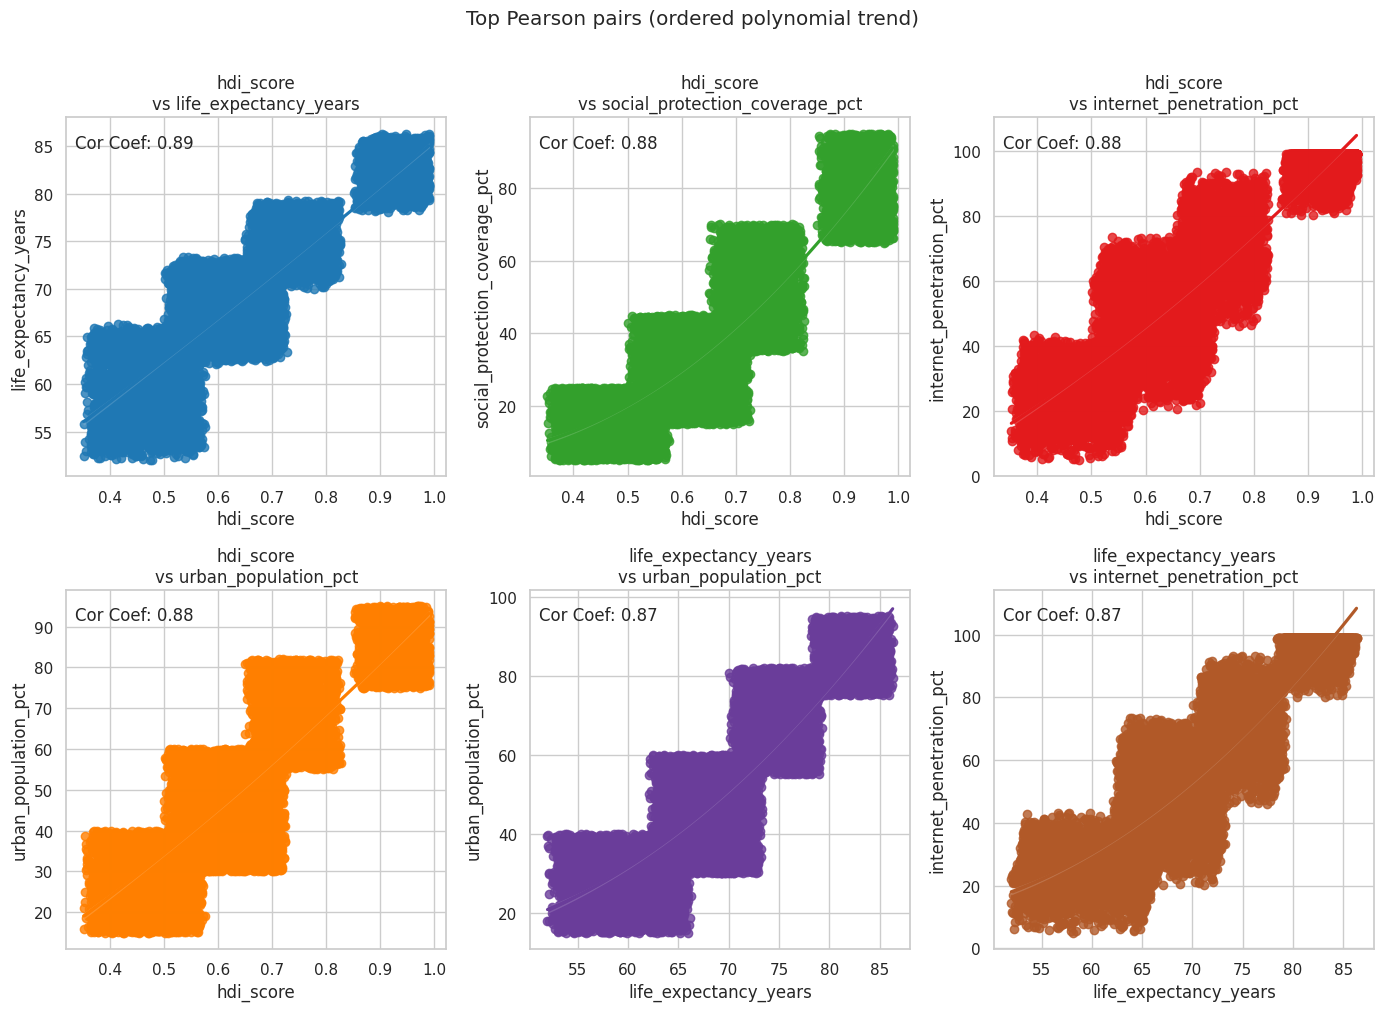

In [9]:
fig = df.nica.rank_correlations_plots(NUM_COLS, n=6, columns=3, polyorder=2, figsize=(14, 10))
fig.suptitle("Top Pearson pairs (ordered polynomial trend)", y=1.01)
plt.tight_layout()
plt.show()


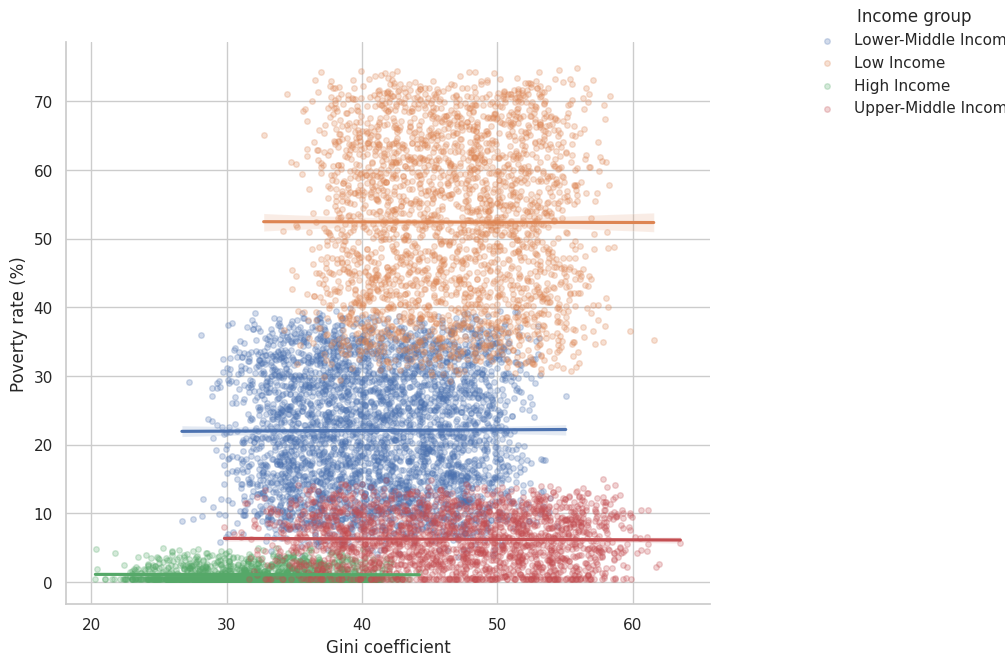

In [10]:
g = sns.lmplot(
    data=df,
    x="gini_coefficient",
    y="poverty_rate_pct",
    hue="income_group",
    scatter_kws={"alpha": 0.25, "s": 16},
    height=6.5,
    aspect=1.22,
)
g.set_axis_labels("Gini coefficient", "Poverty rate (%)")
if g._legend is not None:
    g._legend.set_title("Income group")
    g._legend.set_bbox_to_anchor((1.02, 0.93))
plt.subplots_adjust(right=0.73)
plt.show()


/tmp/ipykernel_16/4105498681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="income_group", y="poverty_rate_pct", ax=axes[0], palette="muted")
/tmp/ipykernel_16/4105498681.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="income_group", y="gini_coefficient", ax=axes[1], palette="muted", inner="quart")


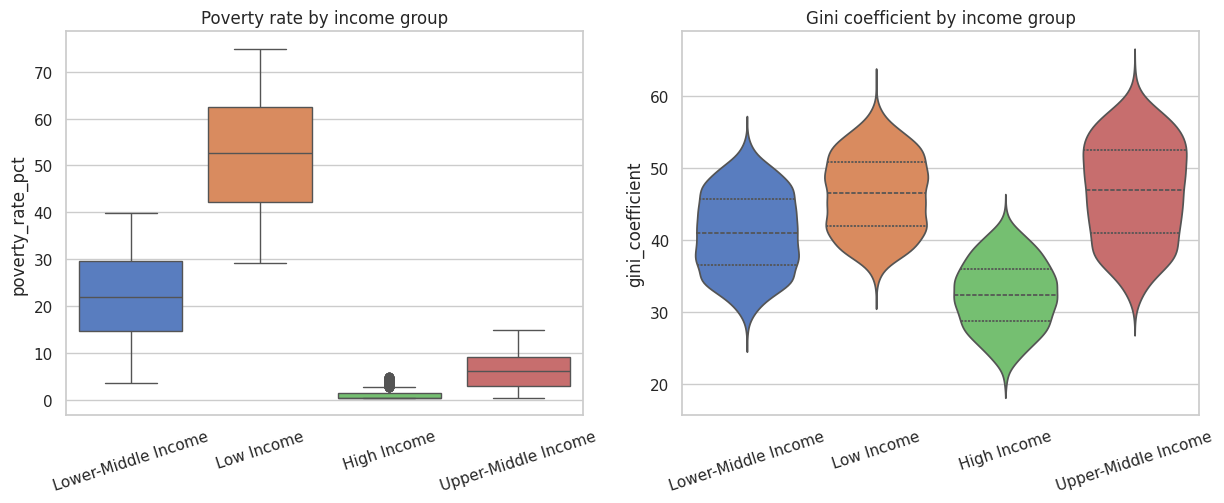

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
sns.boxplot(data=df, x="income_group", y="poverty_rate_pct", ax=axes[0], palette="muted")
axes[0].set_title("Poverty rate by income group")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=18)

sns.violinplot(data=df, x="income_group", y="gini_coefficient", ax=axes[1], palette="muted", inner="quart")
axes[1].set_title("Gini coefficient by income group")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=18)

plt.tight_layout()
plt.show()


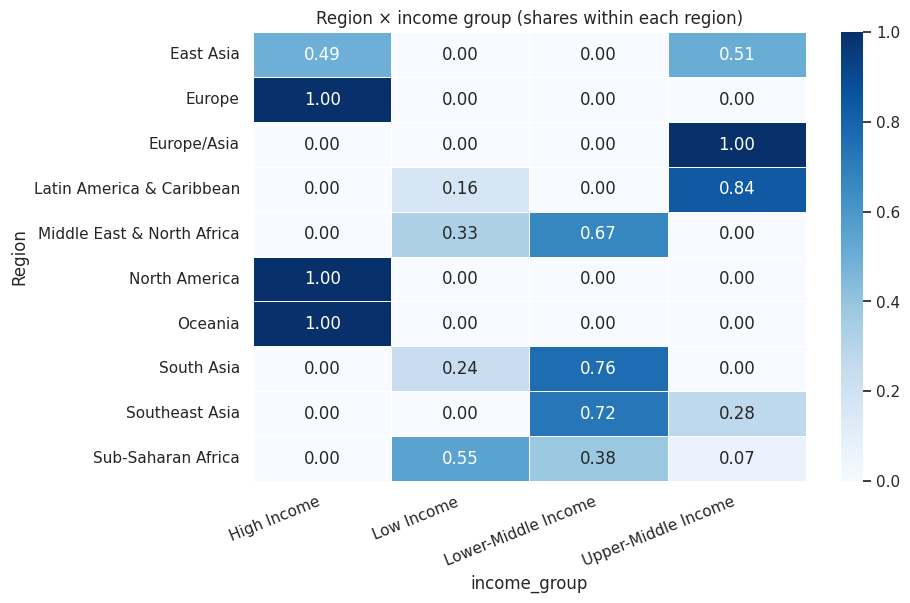

In [12]:
ct = pd.crosstab(df["region"], df["income_group"], normalize="index")
fig, ax = plt.subplots(figsize=(10.8, 6.8))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", linewidths=0.4, ax=ax)
ax.set_title("Region × income group (shares within each region)")
ax.set_ylabel("Region")
plt.xticks(rotation=22, ha="right")
plt.subplots_adjust(bottom=0.22, left=0.28, right=0.92)
plt.show()


/usr/local/lib/python3.12/dist-packages/nicaviz/dataframe_visualizer.py:396: FutureWarning: The provided callable <function mean at 0x7ed43c1ad1c0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = pd.pivot_table(


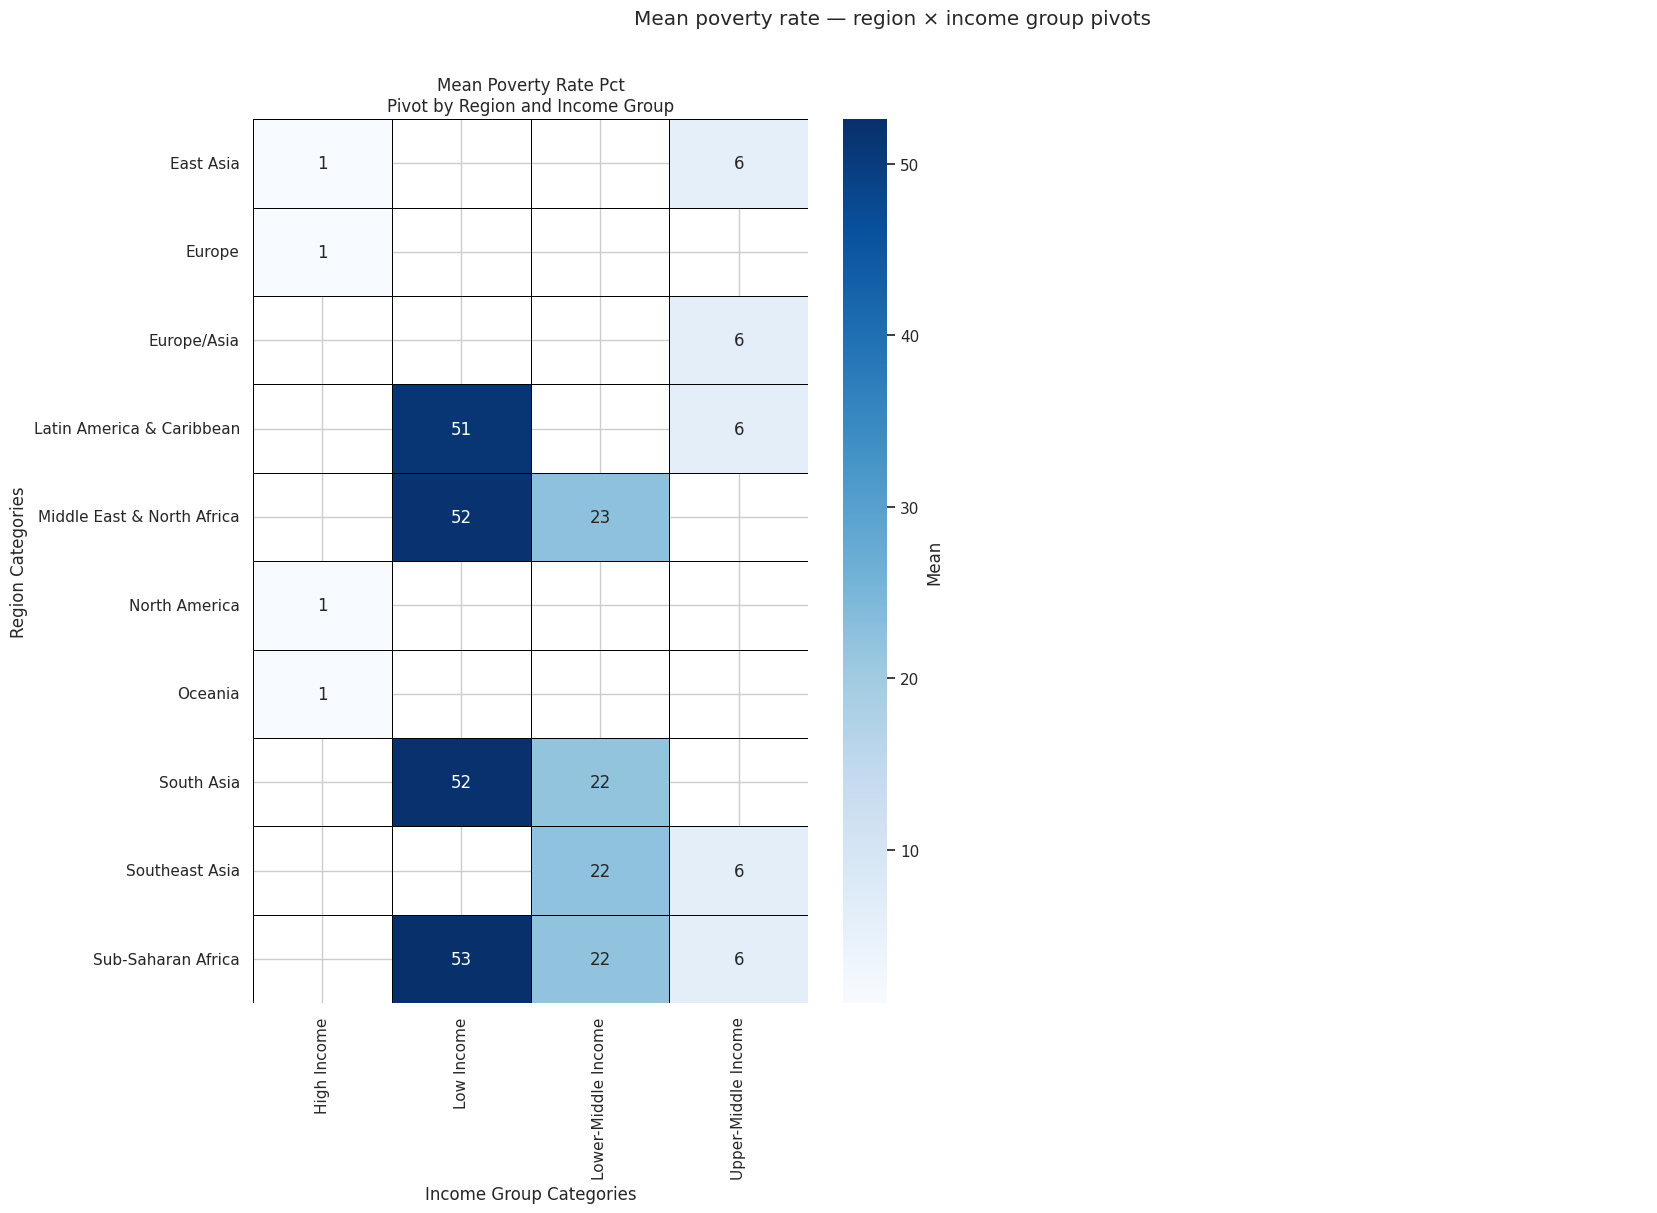

In [13]:
p_df = df[["region", "income_group", "poverty_rate_pct"]].copy()
fig = p_df.nica.pivot_plots(
    ["region", "income_group"],
    "poverty_rate_pct",
    np.mean,
    columns=2,
    figsize=(18, 12),
)
fig.suptitle("Mean poverty rate — region × income group pivots", y=1.01)
plt.tight_layout()
plt.subplots_adjust(right=0.92)
plt.show()


### Synthesis

**Distributions:** the stacked panel shows sizeable dispersion in **poverty** and **Gini**, with welfare and infrastructure variables spanning most of their theoretical ranges — useful anchors for spotting leverage points in regressions beyond this notebook.

**Correlations:** the heatmap plus **`nica.rank_correlations_plots`** highlights which structural variables rise and fall together (e.g., inequality proxies vs poverty/adverse social outcomes)—always contingent on shared geography and sampling.

**Strata:** overlays by **`income_group`** confirm that aggregates differ systematically across World Bank buckets, while the **region × income** tables reveal compositional contrasts that simple marginals omit.
